In [1]:
import torch
import torchmetrics
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import numpy as np
import pandas as pd
import torch.utils.data as data
import random
from tqdm import tqdm

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
train_data = pd.read_csv('train_data.csv')
train_data['SalePrice'] = pd.cut(train_data['SalePrice'], bins=[0, 100000, 350000, float('inf')], labels=[0, 1, 2])

train = train_data.sample(frac=0.75, random_state=42)
remaining = train_data.drop(train.index)
val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

y_train = train.pop('SalePrice')
y_val = val.pop('SalePrice')
y_test = test.pop('SalePrice')

train = pd.get_dummies(train)
val = pd.get_dummies(val)
test = pd.get_dummies(test)

print(f"Train shape: {train.shape}")
print(f"Val shape: {val.shape}")
print(f"Test shape: {test.shape}")


Train shape: (3093, 33)
Val shape: (516, 33)
Test shape: (515, 33)


In [4]:
train_dataset = data.TensorDataset(torch.from_numpy(train.astype(float).values).float(), torch.from_numpy(y_train.values.astype(int)))
val_dataset = data.TensorDataset(torch.from_numpy(val.astype(float).values).float(), torch.from_numpy(y_val.values.astype(int)))
test_dataset = data.TensorDataset(torch.from_numpy(test.astype(float).values).float(), torch.from_numpy(y_test.values.astype(int)))

In [5]:
train_dataloader = data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = data.DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=False)

loaders = {
    'train': train_dataloader,
    'val': val_dataloader,
    'test': test_dataloader
}

In [6]:
class Model(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lin1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.lin2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)

        self.lin3 = nn.Linear(32, 3)

        self.act = nn.ReLU()
    
    def forward(self, x):
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.lin2(x)
        x = self.bn2(x)
        x = self.act(x)
        
        x = self.lin3(x)

        return x

In [7]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [26]:
model = Model(train.shape[1]).to(device)

class_counts = np.bincount(y_train.values.astype(int))
weights = torch.FloatTensor(1.0 / class_counts).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=0.0001)

In [27]:
def training(model, loaders, criterion, optimizer, epochs):

    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task='multiclass', num_classes=3).to(device)
    
    for epoch in range(1, epochs + 1):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            for X_batch, target in tqdm(loaders[phase]):
                X_batch, target = X_batch.to(device), target.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    preds = model(X_batch)
                    loss = criterion(preds, target)

                    metric_loss(loss)
                    metric_acc(preds, target)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
            
            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            
            print(f"Epoch: {epoch}/{epochs}, Loss: {mean_loss}, Accuracy: {acc}")

            metric_loss.reset()
            metric_acc.reset()


In [28]:
training(model, loaders, criterion, optimizer, 100)

100%|██████████| 49/49 [00:00<00:00, 149.62it/s]


Epoch: 1/100, Loss: 1.0988740921020508, Accuracy: 0.6411251425743103


100%|██████████| 9/9 [00:00<00:00, 174.19it/s]


Epoch: 1/100, Loss: 0.9540873765945435, Accuracy: 0.6724806427955627


100%|██████████| 49/49 [00:00<00:00, 126.16it/s]


...

Epoch: 99/100, Loss: 0.2879626750946045, Accuracy: 0.819767415523529


100%|██████████| 49/49 [00:00<00:00, 153.78it/s]


Epoch: 100/100, Loss: 0.30941450595855713, Accuracy: 0.7995473742485046


100%|██████████| 9/9 [00:00<00:00, 221.68it/s]

Epoch: 100/100, Loss: 0.29122987389564514, Accuracy: 0.8275193572044373


array([[<Axes: title={'center': 'gts'}>]], dtype=object)

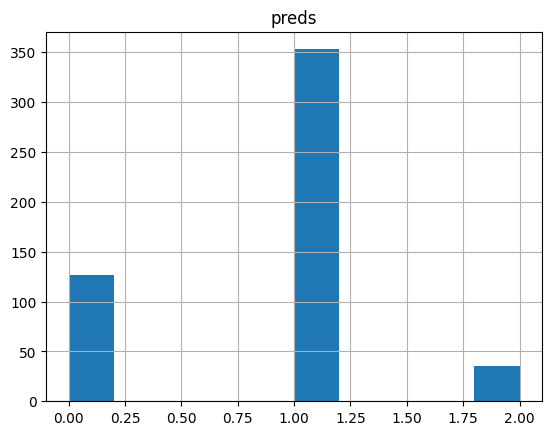

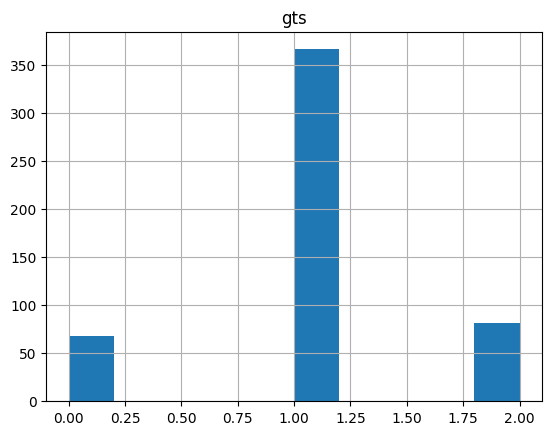

In [40]:
model.eval()
preds = []
gts = []
for x, labels in test_dataloader:
    x, labels = x.to(device), labels.to(device)
    output = model(x)
    pred = output>0
    preds.append(pred.cpu().detach().numpy())
    gts.append(labels.cpu().detach().numpy())
preds = np.argmax(np.concatenate(preds), axis=1)
gts = np.concatenate(gts)

pd.DataFrame(preds, columns=["preds"]).astype(int).hist()
pd.DataFrame(gts.squeeze(), columns=["gts"]).astype(int).hist()